In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:90% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:12pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:12px;}
</style>
"""))

<font size="5" color="black">ch9. Transformer</font>
- 영화평 감성(긍정/부정) 분석

# 1. pkg 불러오기

In [2]:
import numpy as np
from time import time

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import confusion_matrix, recall_score, precision_score, f1_score
import pandas as pd

# 2. 하이퍼 파라미터 설정
- 파라미터 설정에 따라 score와 처리 속도 등이 달라짐

In [51]:
MY_WORDS = 10000 # imdb 데이터셋의 단어 수
MY_LENGTH = 120 # 영화평 단어 수 80개까지 독립 변수
MY_EMBED = 32 # 임베딩 레이어의 출력 차원
MY_HIDDEN = 32 # LSTM의 units 수

MY_EPOCH = 15 # 반복 학습 수
MY_BATCH = 128 # 매번 가져오는 데이터 수

SKIP_TOP = 40 # 불용어 인덱스 설정 (빈도수 상위 40개 제외 : the, a, is 등)

# 3. 데이터 불러오기

In [52]:
(X_train, y_train), (X_test, y_test) = imdb.load_data(
    num_words=MY_WORDS,
    # skip_top=SKIP_TOP
)

# 4. 문자 단어 → 정수 변환

In [53]:
word_to_id = imdb.get_word_index() # dict {'word':idx}

In [54]:
# {'word':id} → {id:'word'} 형태 변경
id_to_word = {}
for word, id in word_to_id.items():
    id_to_word[id] = word

In [55]:
msg = 'What a wonderful movie'
msg = msg.lower().split()

data = [1]+ [word_to_id.get(m, -1) + 3 for m in msg]
data_msg = ' '.join([id_to_word.get(d-3, '??') for d in data])

# 5. 숫자화된 영화평 → 자연어 영화평 변환 함수

In [56]:
def decoding(review_num):
    "숫자화된 영화평을 자연어 영화평으로 바꿔 return"
    decoded = [id_to_word.get(d-3, '??') for d in review_num]
    return ' '.join(decoded)

# 6. 영화평 데이터 길이 출력 함수

In [57]:
def show_length(X_train=X_train, N=10):
    print('영화평 데이터 N개 단어 길이')
    print('N =', N)
    print([len(x_data) for x_data in X_train[:N]])

In [58]:
show_length(N=100)

영화평 데이터 N개 단어 길이
N = 100
[218, 189, 141, 550, 147, 43, 123, 562, 233, 130, 450, 99, 117, 238, 109, 129, 163, 752, 212, 177, 129, 140, 256, 888, 93, 142, 220, 193, 171, 221, 174, 647, 233, 162, 597, 234, 51, 336, 139, 231, 704, 142, 861, 132, 122, 570, 55, 214, 103, 186, 113, 169, 469, 138, 302, 766, 351, 146, 59, 206, 107, 152, 186, 431, 147, 684, 383, 324, 252, 263, 787, 211, 314, 118, 390, 132, 710, 306, 167, 115, 95, 158, 156, 82, 502, 314, 190, 174, 60, 145, 214, 659, 408, 515, 461, 202, 238, 170, 107, 171]


In [59]:
# 영화평 단어 길이 최댓값과 최솟값
max(len(x) for x in X_train), min(len(x) for x in X_train)

(2494, 11)

# 7. 모든 영화평 길이 통일
- 기준 : MY_LENGTH
- pad_sequences 활용

In [60]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((25000,), (25000,), (25000,), (25000,))

In [61]:
X_train = pad_sequences(X_train,
                        maxlen=MY_LENGTH,
                        truncating='post',
                        padding='pre',
                        )

X_test = pad_sequences(X_test,
                       maxlen=MY_LENGTH,
                       truncating='post',
                       padding='pre',
                       )
show_length(X_train)
show_length(X_test)

영화평 데이터 N개 단어 길이
N = 10
[120, 120, 120, 120, 120, 120, 120, 120, 120, 120]
영화평 데이터 N개 단어 길이
N = 10
[120, 120, 120, 120, 120, 120, 120, 120, 120, 120]


In [62]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((25000, 120), (25000,), (25000, 120), (25000,))

 ## Transformer (트랜스포머)
- 위치 인코딩 ($PE$ - 순서 번호표) : 순차 처리 없이 병렬 입력된 단어들의 위치/순서 정보를 임베딩에 추가해 주는 역할
- $Q, K, V$ 행렬 (정보 대조군) : 단어 간 연관성을 계산하기 위해 가중치를 곱해 생성한 3가지 핵심 벡터
- 인코더 출력 ($H_{enc}$ - 문맥 종합 보고서) : 입력 문장 전체의 단어들이 서로의 문맥을 완벽히 흡수하여 생성된 배경 지식 표현
- 디코더 은닉 상태 ($h_{dec}$ - 생성용 진행 상태) : 지금까지 생성한 단어들과 인코더 보고서를 종합해 다음 단어를 예측하는 상태


- 연산 레이어 (핵심 부서)
    * 셀프 어텐션 (Self-Attention) : 문장 내 모든 단어가 서로를 참조하여 어떤 단어와 연관성이 높은지 스케일드 닷 프로덕트로 계산
    * 멀티 헤드 어텐션 (Multi-Head Attention) : $Q, K, V$를 여러 개로 나누어(Head) 문법, 의미, 대명사 추적 등 다양한 관점에서 동시에 관계를 분석
    * 마스크드 셀프 어텐션 (Masked Self-Attention) : 디코더에서 미래 시점의 단어를 미리 보고 답을 베끼지 못하도록 뒤쪽 단어들을 가리는 연산
    * 인코더-디코더 어텐션 (Cross-Attention) : 디코더의 Query가 인코더의 Key-Value(문맥 보고서)를 참조하여 번역/생성에 필요한 정보를 추출
    * 피드포워드 네트워크 (FFN) : 어텐션으로 모은 관계 정보를 바탕으로 각 단어 개별적인 의미를 최종 변환 및 정립

---

* 동작 방식 및 순서 (인코더 ➔ 디코더 전체 흐름)<br>
[1. 위치 표시 및 병렬 입력] ──► [2. 인코더 문맥 분석] ──► [3. 인코더 보고서 완성] ──► [4. 디코더 단어 생성 & 마스킹] ──► [5. 교차 참조 및 최종 예측]


1. 위치 표시 및 병렬 입력 : 문장 전체 단어 임베딩에 위치 인코딩($PE$)을 더해 순서 정보를 부여한 뒤 한 번에 병렬 입력
2. 인코더 문맥 분석 : 멀티 헤드 셀프 어텐션을 통해 모든 단어가 서로의 연관성을 계산하고, 피드포워드(FFN)를 거쳐 의미를 정립
3. 인코더 보고서 완성 : 잔차 연결(Residual Connection)과 레이어 정규화를 거쳐 문장 전체의 관계가 담긴 '문맥 종합 보고서($H_{enc}$)' 완성
4. 디코더 단어 생성 & 마스킹 : 디코더는 지금까지 생성된 단어들에 마스크드 셀프 어텐션을 적용해 미래 단어 유출을 막으며 현재 맥락을 파악
5. 교차 참조 및 최종 예측 : 크로스 어텐션으로 인코더 보고서($H_{enc}$)에서 필요한 정보를 가져온 뒤, Softmax를 거쳐 다음 시점의 가장 적절한 단어를 출력


# 8. 모델 생성 구현 - 다중 분류

In [63]:
from tensorflow import range
from tensorflow.keras.layers import Dropout, MultiHeadAttention, add, Input, BatchNormalization, LayerNormalization, GlobalAvgPool1D
from tensorflow.keras.models import Model

In [64]:
# input
INPUTS = Input(shape=(MY_LENGTH,))
INPUT_EMBEDDING = Embedding(
    input_dim = MY_WORDS,
    output_dim = MY_EMBED
)(INPUTS)

# positional encoding
POSITIONS = range(start=0, limit=MY_LENGTH)
POS_ENCODING = Embedding(
    input_dim=MY_LENGTH,
    output_dim=MY_EMBED
)(POSITIONS)
POS_ENC_OUTPUT = POS_ENCODING + INPUT_EMBEDDING

# multi-head attention
ATTENTION_OUTPUT = MultiHeadAttention(
    num_heads=3,
    key_dim=MY_EMBED//3,
    dropout=0.4
)(POS_ENC_OUTPUT, # self-attention
  POS_ENC_OUTPUT)

# add & norm
X = add([POS_ENC_OUTPUT, ATTENTION_OUTPUT])
X = LayerNormalization()(X)

# feed forword
FFN = Sequential([
    Dense(
        units=MY_HIDDEN, 
        activation='elu', 
        kernel_regularizer=l2(0.001), 
        kernel_initializer='he_normal'),
    Dropout(0.4),
    Dense(
        units=MY_EMBED,
        activation=None,
        kernel_regularizer=l2(0.001))
])(X)

X = add([FFN, X])
X = LayerNormalization()(X)

# 1D comp.
X = GlobalAvgPool1D()(X)
X = Dropout(0.4)(X)

# output
X = Dense(
    MY_HIDDEN, 
    activation='elu',
    kernel_regularizer=l2(0.001), 
    kernel_initializer='he_normal')(X)
X = Dropout(0.4)(X)
OUTPUTS = Dense(2, activation='softmax')(X)

model = Model(inputs=INPUTS, outputs=OUTPUTS, name='model')
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_3 (InputLayer)           [(None, 120)]        0           []                               
                                                                                                  
 embedding_4 (Embedding)        (None, 120, 32)      320000      ['input_3[0][0]']                
                                                                                                  
 tf.__operators__.add_2 (TFOpLa  (None, 120, 32)     0           ['embedding_4[0][0]']            
 mbda)                                                                                            
                                                                                                  
 multi_head_attention_2 (MultiH  (None, 120, 32)     3962        ['tf.__operators__.add_2[0][0

# 9. 학습과정 설정 및 학습

In [65]:
# 다중 분류
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['acc'])

In [66]:
begin = time()

earlyStopping = EarlyStopping(
    monitor='val_loss', 
    patience=3, 
    mode='min', 
    restore_best_weights=True,
    verbose=1
)

hist = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=MY_EPOCH,
    batch_size=MY_BATCH,
    verbose=2,
    callbacks=[earlyStopping]
)

end = time()

print(f'총 학습시간 : {round(end - begin, 2)}초')

Epoch 1/15
157/157 - 38s - loss: 0.6876 - acc: 0.7138 - val_loss: 0.5147 - val_acc: 0.8294 - 38s/epoch - 241ms/step
Epoch 2/15
157/157 - 36s - loss: 0.4322 - acc: 0.8680 - val_loss: 0.4781 - val_acc: 0.8448 - 36s/epoch - 231ms/step
Epoch 3/15
157/157 - 36s - loss: 0.3293 - acc: 0.9077 - val_loss: 0.4774 - val_acc: 0.8362 - 36s/epoch - 232ms/step
Epoch 4/15
157/157 - 34s - loss: 0.2680 - acc: 0.9233 - val_loss: 0.5490 - val_acc: 0.8210 - 34s/epoch - 216ms/step
Epoch 5/15
157/157 - 35s - loss: 0.2150 - acc: 0.9420 - val_loss: 0.5896 - val_acc: 0.8184 - 35s/epoch - 220ms/step
Epoch 6/15
Restoring model weights from the end of the best epoch: 3.
157/157 - 36s - loss: 0.1857 - acc: 0.9477 - val_loss: 0.6137 - val_acc: 0.8178 - 36s/epoch - 232ms/step
Epoch 6: early stopping
총 학습시간 : 215.37초


# 10. 모델 평가

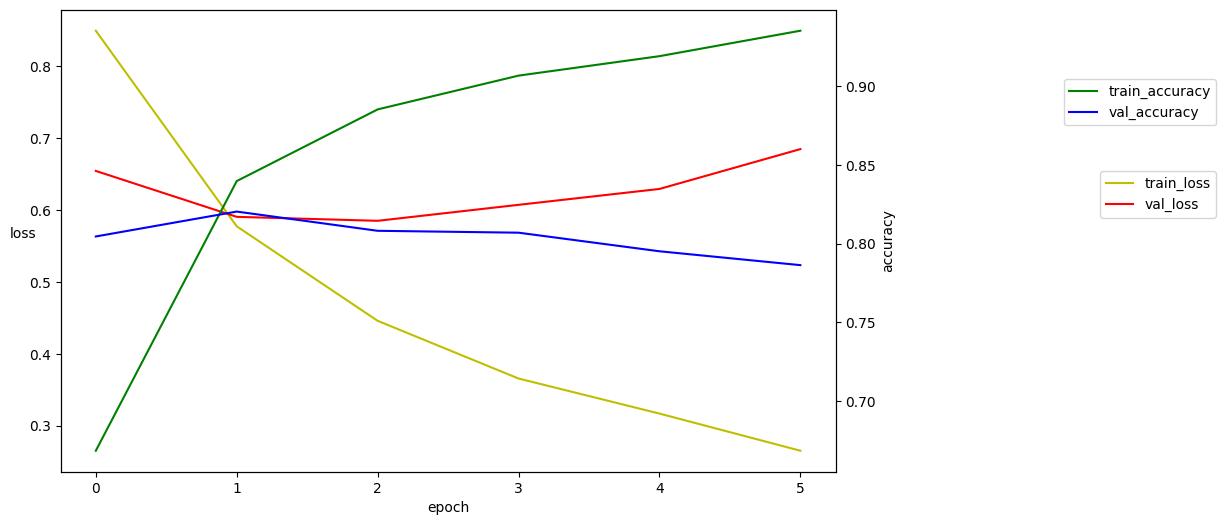

In [31]:
import matplotlib.pyplot as plt

fig, loss_ax = plt.subplots(figsize=(10,6))
loss_ax.plot(hist.history['loss'], 'y', label='train_loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val_loss')
loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss', rotation=0)

acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['acc'], 'g', label='train_accuracy')
acc_ax.plot(hist.history['val_acc'], 'b', label='val_accuracy')
acc_ax.set_ylabel('accuracy')
loss_ax.legend(loc='center right', bbox_to_anchor=(1.5, 0.6), ncol=1)
acc_ax.legend(loc='center right', bbox_to_anchor=(1.5, 0.8), ncol=1)
plt.show()

In [49]:
loss, acc = model.evaluate(X_test, y_test)

782/782 [==============================] - 11s 13ms/step - loss: 1.8510 - acc: 0.4935


In [33]:
# 혼돈 행렬을 위한 예측값
pred = model.predict(X_test, batch_size=MY_BATCH)
y_hat = pred.argmax(axis=1)

125/125 [==============================] - 7s 56ms/step


In [34]:
confusion_matrix(y_test, y_hat)

array([[6236, 6264],
       [6398, 6102]], dtype=int64)

In [35]:
pd.crosstab(y_test, y_hat.reshape(-1))

col_0,0,1
row_0,,
0,6236,6264
1,6398,6102


In [36]:
print('recall :', recall_score(y_test, y_hat))
print('precision :', precision_score(y_test, y_hat))
print('f1-score :', f1_score(y_test, y_hat))

recall : 0.48816
precision : 0.49344978165938863
f1-score : 0.4907906378187083


# 11. 모델 사용하기

In [41]:
review = '''I was just fine with everything. Actually, I think it would have been fine even if it wasn’t IMAX
The overwhelming impact of the 4:3 aspect ratio shone through in some scenes, but
Overall, "Cinematography" is just cool
And the casting that didn’t fit at all didn’t cause any problems for either my wife and me
The moment when the first godic being Odysseus encounters after leaving Troy
The audience (at least my wife and I) already feel like we’ve fallen right in the middle of the stage in the myth, so
No matter who I saw—Asian actors, Indian actors, or Black actors—it didn’t bother me'''.lower()
import re
review = re.sub('[^a-zA-Z\s]', ' ', review).split()
review = [1] + [word_to_id.get(word, -1) + 3 if (word_to_id.get(word, -1) + 3)<10000 else 2 for word in review]

In [42]:
input_data = pad_sequences(
    [review],
    maxlen=MY_LENGTH,
    truncating='post',
    padding='pre',
    )
input_data.shape

(1, 80)

In [45]:
model.predict(input_data).argmax(axis=1)

1/1 [==============================] - 0s 32ms/step


array([1], dtype=int64)

In [46]:
review = '''They say the higher the expectations, the bigger the disappointment, 
and that completely sums up this movie. While the fresh premise and flashy visuals 
initially caught my eye, it stopped right there. By the middle, the plot completely 
lost its logic, making the characters' actions impossible to understand.
The lines were so cheesy and cliché that it felt like a waste of the actors' solid 
performances. Dragging scenes had me constantly checking my watch, and even the 
climax left me feeling flat. The story got so tangled that it was hard to guess 
what message the director was try'''.lower()
review = [1] + [word_to_id.get(r, -1)+3 for r in review]
input_data = pad_sequences([review],
               maxlen=MY_LENGTH,
               truncating='post', # 80단어 이상일 경우 어디를 짜를지 여부
               padding='pre', # 80단어 미만일 경우 앞에 zero를 붙임
               )
model.predict(input_data).argmax(axis=1)

1/1 [==============================] - 0s 34ms/step


array([1], dtype=int64)